# Capítulo 12 — Precision, recall y F1-score

En el capítulo anterior usamos la accuracy y la matriz de confusión para distinguir los aciertos y los errores de un clasificador. En este cuaderno avanzaremos un paso más: calcularemos métricas que permiten observar con mayor detalle qué ocurre con la clase positiva.

Primero reconstruiremos `precision`, `recall` y `F1-score` a partir de una matriz sencilla. Luego veremos cómo cambian cuando modificamos el umbral de un modelo real.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- calcular precision, recall y F1-score a partir de una matriz de confusión;
- interpretar qué pregunta responde cada métrica;
- reconocer la relación entre falsos positivos y precision;
- reconocer la relación entre falsos negativos y recall;
- explicar qué resume el F1-score y cuáles son sus límites;
- observar cómo el umbral modifica las tres métricas;
- elegir qué métrica priorizar según las consecuencias de los errores.


## 1. Importar las herramientas

Usaremos funciones de `scikit-learn` para comprobar los cálculos manuales y para evaluar un clasificador. También utilizaremos Pandas y Matplotlib para organizar y visualizar los resultados.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 2. Partir de una matriz de confusión conocida

Retomemos el ejemplo de abandono de clientes del capítulo teórico. Definimos:

```text
Clase positiva: abandona
Clase negativa: permanece
```

La matriz contiene 50 verdaderos negativos, 10 falsos positivos, 15 falsos negativos y 25 verdaderos positivos. Construiremos dos vectores que reproduzcan exactamente esos cien resultados.


In [2]:
y_real_manual = np.array(
    [0] * 60 + [1] * 40
)

y_pred_manual = np.array(
    [0] * 50 + [1] * 10
    + [0] * 15 + [1] * 25
)

matriz_manual = confusion_matrix(
    y_real_manual,
    y_pred_manual,
    labels=[0, 1],
)

matriz_manual


array([[50, 10],
       [15, 25]])


En la primera fila están los 60 clientes que realmente permanecieron: 50 fueron clasificados correctamente y 10 fueron falsas alarmas. En la segunda fila están los 40 que realmente abandonaron: 25 fueron detectados y 15 pasaron inadvertidos.


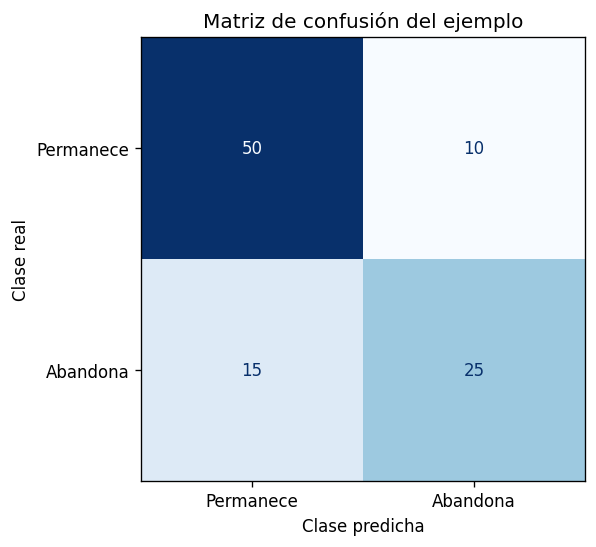

In [3]:
ConfusionMatrixDisplay(
    confusion_matrix=matriz_manual,
    display_labels=["Permanece", "Abandona"],
).plot(
    cmap="Blues",
    colorbar=False,
)

plt.title("Matriz de confusión del ejemplo")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()


La matriz será nuestro punto de partida. Las tres métricas del capítulo se construyen con cantidades que ya conocemos:

- precision utiliza verdaderos positivos y falsos positivos;
- recall utiliza verdaderos positivos y falsos negativos;
- F1-score combina precision y recall.


## 3. Calcular precision

Precision responde:

> **De todos los casos que el modelo predijo como positivos, ¿cuántos eran realmente positivos?**

Su fórmula es:

```text
precision = VP / (VP + FP)
```


In [4]:
vn, fp, fn, vp = matriz_manual.ravel()

precision_manual = vp / (vp + fp)

pd.DataFrame({
    "VP": [vp],
    "FP": [fp],
    "positivos_predichos": [vp + fp],
    "precision": [precision_manual],
}).round(3)


,VP,FP,positivos_predichos,precision
0,25,10,35,0.714


El modelo predijo “abandona” en 35 casos. De ellos, 25 eran abandonos reales. Por eso, su precision es aproximadamente `0,714`: alrededor de siete de cada diez alertas positivas fueron correctas.

Los 10 falsos positivos reducen esta métrica. En este contexto representan clientes contactados o incentivados aunque en realidad iban a permanecer.


In [5]:
precision_sklearn = precision_score(
    y_real_manual,
    y_pred_manual,
)

print(f"Precision manual:            {precision_manual:.3f}")
print(f"Precision con scikit-learn:  {precision_sklearn:.3f}")


Precision manual:            0.714
Precision con scikit-learn:  0.714


Los dos resultados coinciden. `precision_score()` realiza el mismo cálculo, considerando por defecto que la clase `1` es la positiva.


## 4. Calcular recall

Recall responde otra pregunta:

> **De todos los casos que realmente eran positivos, ¿cuántos logró detectar el modelo?**

Su fórmula es:

```text
recall = VP / (VP + FN)
```


In [6]:
recall_manual = vp / (vp + fn)

pd.DataFrame({
    "VP": [vp],
    "FN": [fn],
    "positivos_reales": [vp + fn],
    "recall": [recall_manual],
}).round(3)


,VP,FN,positivos_reales,recall
0,25,15,40,0.625


Había 40 clientes que realmente abandonaron y el modelo detectó 25. El recall es `0,625`: se identificó el 62,5% de los abandonos reales.

Los 15 falsos negativos reducen esta métrica. Son clientes que abandonaron, pero que el sistema no señaló como casos de riesgo.


In [7]:
recall_sklearn = recall_score(
    y_real_manual,
    y_pred_manual,
)

print(f"Recall manual:            {recall_manual:.3f}")
print(f"Recall con scikit-learn:  {recall_sklearn:.3f}")


Recall manual:            0.625
Recall con scikit-learn:  0.625


Otra vez, el cálculo manual y el resultado de `scikit-learn` coinciden. Precision mira las predicciones positivas; recall mira los positivos reales. Esa diferencia explica por qué las dos métricas pueden cambiar de manera distinta.


## 5. Calcular el F1-score

El F1-score combina precision y recall mediante:

```text
F1 = 2 · (precision · recall) / (precision + recall)
```

Será alto solamente cuando ambas métricas sean razonablemente altas. Si una de ellas cae, el F1-score también se ve afectado.


In [8]:
f1_manual = (
    2
    * precision_manual
    * recall_manual
    / (precision_manual + recall_manual)
)

f1_sklearn = f1_score(
    y_real_manual,
    y_pred_manual,
)

pd.DataFrame({
    "precision": [precision_manual],
    "recall": [recall_manual],
    "F1_manual": [f1_manual],
    "F1_sklearn": [f1_sklearn],
}).round(3)


,precision,recall,F1_manual,F1_sklearn
0,0.714,0.625,0.667,0.667


El F1-score es aproximadamente `0,667`. Resume el equilibrio entre una precision de `0,714` y un recall de `0,625`, pero no reemplaza la lectura individual de esas métricas.


## 6. Un mismo F1-score puede ocultar comportamientos diferentes

El F1-score es útil como resumen, pero un único número no muestra qué clase de error domina. Comparemos dos situaciones hipotéticas: una prioriza alertas confiables y otra intenta cubrir más positivos reales.


In [9]:
escenarios_f1 = pd.DataFrame({
    "escenario": [
        "Alertas más selectivas",
        "Detección más amplia",
        "Equilibrio",
    ],
    "precision": [0.80, 0.50, 0.65],
    "recall": [0.50, 0.80, 0.65],
})

escenarios_f1["F1"] = (
    2
    * escenarios_f1["precision"]
    * escenarios_f1["recall"]
    / (
        escenarios_f1["precision"]
        + escenarios_f1["recall"]
    )
)

escenarios_f1.round(3)


,escenario,precision,recall,F1
0,Alertas más selectivas,0.80,0.50,0.615
1,Detección más amplia,0.50,0.80,0.615
2,Equilibrio,0.65,0.65,0.650


Los dos primeros escenarios tienen el mismo F1-score, aunque su comportamiento es muy distinto:

- el primero genera alertas más confiables, pero detecta menos positivos;
- el segundo detecta más positivos, pero produce más falsas alarmas.

El tercer escenario obtiene un F1-score algo mayor porque precision y recall están equilibradas. Aun así, el contexto podría justificar elegir uno de los otros dos.


## 7. Preparar un problema de clasificación real

Continuaremos con el dataset Breast Cancer Wisconsin utilizado en el cuaderno anterior. Cada fila contiene mediciones obtenidas a partir de imágenes digitalizadas de muestras celulares.

Lo usaremos exclusivamente como ejemplo educativo. Este cuaderno no constituye una herramienta médica y sus resultados no deben utilizarse para tomar decisiones clínicas.


In [10]:
datos = load_breast_cancer(as_frame=True)

X = datos.data

# En el dataset original, 0 significa maligno y 1 benigno.
# Reordenamos los códigos para definir "maligna" como clase positiva.
y = (datos.target == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "filas": [len(y_train), len(y_test)],
    "casos_malignos": [y_train.sum(), y_test.sum()],
    "porcentaje_malignos": [
        y_train.mean() * 100,
        y_test.mean() * 100,
    ],
}).round(1)


,conjunto,filas,casos_malignos,porcentaje_malignos
0,Entrenamiento,426,159,37.3
1,Prueba,143,53,37.1


La separación conserva una proporción semejante de casos malignos en entrenamiento y prueba. La clase positiva es `1`, que en este ejemplo significa **muestra maligna**.

Esta definición es fundamental: precision, recall y F1-score se calcularán desde el punto de vista de esa clase.


In [11]:
modelo = Pipeline([
    ("escalador", StandardScaler()),
    ("logistica", LogisticRegression(
        max_iter=1000,
        random_state=42,
    )),
])

modelo.fit(X_train, y_train)

print("Modelo entrenado.")


Modelo entrenado.


Usamos una regresión logística dentro de un `Pipeline`, como en los cuadernos anteriores. El objetivo no es volver a estudiar el algoritmo, sino disponer de probabilidades para analizar cómo cambian las métricas.


## 8. Evaluar el modelo con el umbral 0,5

Primero utilizaremos el umbral habitual de `0,5`. Calcularemos accuracy para conservar la referencia del capítulo anterior, pero el foco estará puesto en precision, recall y F1-score.


In [12]:
prob_maligna = modelo.predict_proba(X_test)[:, 1]
pred_umbral_05 = (prob_maligna >= 0.5).astype(int)

metricas_05 = pd.DataFrame({
    "métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
    "valor": [
        accuracy_score(y_test, pred_umbral_05),
        precision_score(y_test, pred_umbral_05),
        recall_score(y_test, pred_umbral_05),
        f1_score(y_test, pred_umbral_05),
    ],
})

metricas_05.round(3)


,métrica,valor
0,Accuracy,0.965
1,Precision,0.980
2,Recall,0.925
3,F1-score,0.951


Con este umbral, la precision es `0,980`: casi todas las muestras marcadas como malignas realmente lo eran. El recall es `0,925`: el modelo detectó la mayor parte de los casos malignos, pero no todos. El F1-score, `0,951`, resume ese comportamiento conjunto.


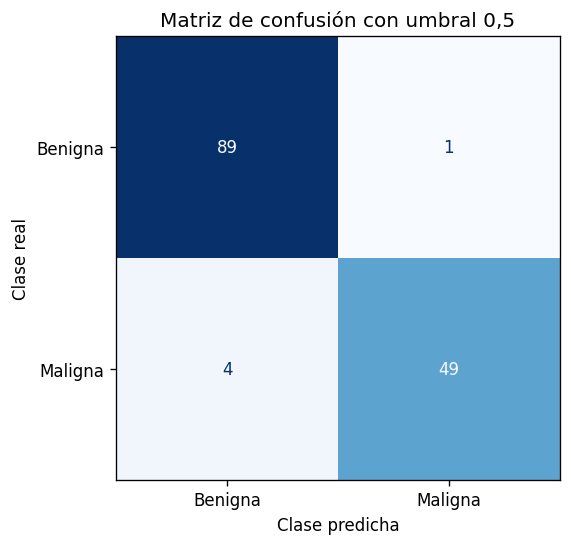

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_umbral_05,
    labels=[0, 1],
    display_labels=["Benigna", "Maligna"],
    cmap="Blues",
    colorbar=False,
)

plt.title("Matriz de confusión con umbral 0,5")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()


La matriz explica las métricas: hay un falso positivo y cuatro falsos negativos. La única falsa alarma afecta a precision; los cuatro casos malignos no detectados afectan a recall.


## 9. Observar el efecto del umbral

El modelo produce probabilidades. Al cambiar el umbral que las convierte en clases, cambian las predicciones y, por lo tanto, también cambian las métricas.

Compararemos cinco umbrales para observar la tendencia. No estamos eligiendo aquí un umbral definitivo: el propósito es estudiar cómo se modifica el comportamiento del mismo modelo.


In [14]:
resultados_umbrales = []

for umbral in [0.1, 0.3, 0.5, 0.7, 0.9]:
    predicciones = (
        prob_maligna >= umbral
    ).astype(int)

    vn_u, fp_u, fn_u, vp_u = confusion_matrix(
        y_test,
        predicciones,
        labels=[0, 1],
    ).ravel()

    resultados_umbrales.append({
        "umbral": umbral,
        "positivos_predichos": predicciones.sum(),
        "FP": fp_u,
        "FN": fn_u,
        "precision": precision_score(
            y_test,
            predicciones,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predicciones,
            zero_division=0,
        ),
        "F1": f1_score(
            y_test,
            predicciones,
            zero_division=0,
        ),
    })

tabla_umbrales = pd.DataFrame(resultados_umbrales)
tabla_umbrales.round(3)


,umbral,positivos_predichos,FP,FN,precision,recall,F1
0,0.1,58,6,1,0.897,0.981,0.937
1,0.3,52,1,2,0.981,0.962,0.971
2,0.5,50,1,4,0.980,0.925,0.951
3,0.7,48,0,5,1.000,0.906,0.950
4,0.9,43,0,10,1.000,0.811,0.896


La tendencia coincide con lo desarrollado en el capítulo:

- con umbral `0,1`, el modelo detecta 52 de los 53 casos malignos, pero genera seis falsas alarmas;
- con umbral `0,9`, no genera falsos positivos, pero deja sin detectar diez casos malignos;
- los umbrales intermedios ofrecen otros equilibrios.

Subir el umbral hace que las alertas sean más selectivas. Bajarlo permite detectar más positivos reales, a costa de aceptar más falsos positivos.


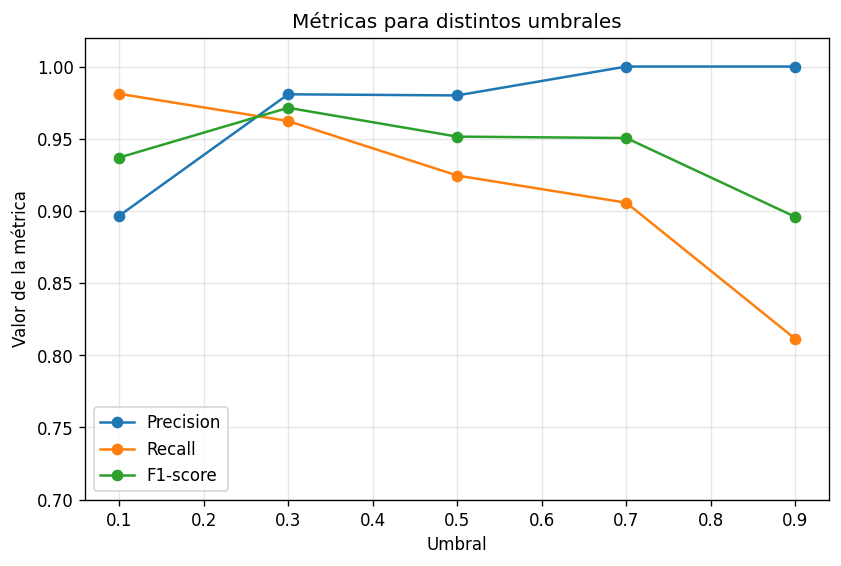

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_umbrales["umbral"],
    tabla_umbrales["precision"],
    marker="o",
    label="Precision",
)
plt.plot(
    tabla_umbrales["umbral"],
    tabla_umbrales["recall"],
    marker="o",
    label="Recall",
)
plt.plot(
    tabla_umbrales["umbral"],
    tabla_umbrales["F1"],
    marker="o",
    label="F1-score",
)

plt.title("Métricas para distintos umbrales")
plt.xlabel("Umbral")
plt.ylabel("Valor de la métrica")
plt.ylim(0.70, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


El gráfico ayuda a comparar las métricas, pero no decide por nosotros. Un umbral puede ofrecer el F1-score más alto entre los valores probados y aun así no ser adecuado si el problema exige reducir especialmente los falsos positivos o los falsos negativos.


## 10. Comparar los errores que produce cada umbral

Veamos las matrices correspondientes a un umbral bajo, uno intermedio y uno alto. Así podremos conectar las métricas con errores concretos.


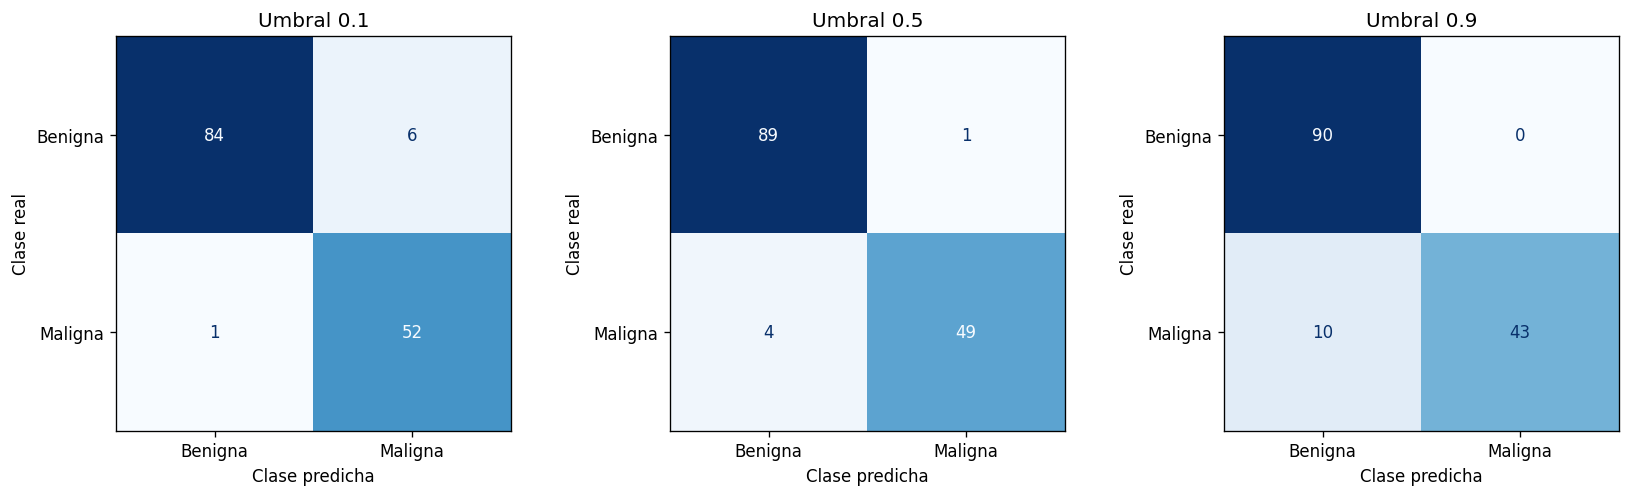

In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(14, 4.2))

for eje, umbral in zip(
    ejes,
    [0.1, 0.5, 0.9],
):
    predicciones = (
        prob_maligna >= umbral
    ).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicciones,
        labels=[0, 1],
        display_labels=["Benigna", "Maligna"],
        cmap="Blues",
        colorbar=False,
        ax=eje,
    )

    eje.set_title(f"Umbral {umbral:.1f}")
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")

plt.tight_layout()
plt.show()


Las matrices muestran el intercambio con claridad:

- el umbral `0,1` deja solo un falso negativo, pero produce seis falsos positivos;
- el umbral `0,5` reduce las falsas alarmas a una, pero deja cuatro falsos negativos;
- el umbral `0,9` elimina los falsos positivos, pero deja diez casos malignos sin detectar.

Ninguna de estas decisiones puede juzgarse solo por su posición en la tabla. Necesitamos saber qué error es más importante controlar.


## 11. Priorizar precision, recall o equilibrio

Podemos resumir tres decisiones posibles:

- **priorizar recall:** reducir los falsos negativos y detectar más positivos reales;
- **priorizar precision:** reducir los falsos positivos y producir alertas más confiables;
- **buscar equilibrio:** considerar ambas métricas mediante F1-score.


In [17]:
resumen_decisiones = (
    tabla_umbrales[
        tabla_umbrales["umbral"].isin(
            [0.1, 0.3, 0.9]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

resumen_decisiones.insert(
    0,
    "criterio_ilustrativo",
    [
        "Mayor cobertura",
        "Mayor F1 entre los probados",
        "Alertas más selectivas",
    ],
)

resumen_decisiones.round(3)


,criterio_ilustrativo,umbral,positivos_predichos,FP,FN,precision,recall,F1
0,Mayor cobertura,0.1,58,6,1,0.897,0.981,0.937
1,Mayor F1 entre los probados,0.3,52,1,2,0.981,0.962,0.971
2,Alertas más selectivas,0.9,43,0,10,1.000,0.811,0.896


En este ejemplo:

- `0,1` ofrece el mayor recall, porque intenta no dejar pasar muestras malignas;
- `0,9` ofrece precision perfecta, porque todas sus alertas positivas son correctas;
- `0,3` produce el mayor F1-score entre los cinco umbrales probados.

Esto no convierte a `0,3` en una elección universalmente mejor. Si un falso negativo fuera especialmente grave, podríamos preferir mayor recall. Si una falsa alarma tuviera consecuencias difíciles de revertir, podríamos exigir mayor precision.


In [18]:
fila_mejor_f1 = tabla_umbrales.loc[
    tabla_umbrales["F1"].idxmax()
]

print(
    "Mayor F1 entre los umbrales probados:",
    f"{fila_mejor_f1['F1']:.3f}",
)
print(
    "Umbral correspondiente:",
    f"{fila_mejor_f1['umbral']:.1f}",
)
print(
    "Precision:",
    f"{fila_mejor_f1['precision']:.3f}",
)
print(
    "Recall:",
    f"{fila_mejor_f1['recall']:.3f}",
)


Mayor F1 entre los umbrales probados: 0.971
Umbral correspondiente: 0.3
Precision: 0.981
Recall: 0.962


El cálculo confirma cuál fue el mejor equilibrio **dentro de este pequeño conjunto de umbrales**. No demuestra que ese valor sea óptimo para otros datos ni que sea la decisión correcta para un uso real.


## 12. Elegir la métrica según el contexto

La métrica principal debe relacionarse con el error que más importa:

| Situación | Error especialmente relevante | Métrica a observar con atención |
|---|---|---|
| Filtro de spam que podría ocultar correos legítimos | Falso positivo | Precision |
| Detección de casos que requieren revisión | Falso negativo | Recall |
| Alertas de seguridad con capacidad limitada de análisis | Falsos positivos y carga operativa | Precision, sin ignorar recall |
| Detección de amenazas que no deberían pasar inadvertidas | Falso negativo | Recall, sin ignorar precision |
| Problema desbalanceado donde ambos errores importan | Ambos | F1-score, junto con precision y recall |

Esta tabla no es una regla automática. En cada proyecto deben analizarse las consecuencias reales, la capacidad de intervención y la forma en que se usarán las predicciones.


## 13. Una pequeña exploración

Probá otros umbrales y observá cómo cambia el comportamiento del modelo. Podés modificar la lista de la siguiente celda. Evitá interpretar el valor con mayor F1 como una respuesta automática: revisá también falsos positivos, falsos negativos, precision y recall.


In [19]:
umbrales_actividad = [
    0.15,
    0.35,
    0.55,
    0.75,
    0.95,
]

resultados_actividad = []

for umbral in umbrales_actividad:
    predicciones = (
        prob_maligna >= umbral
    ).astype(int)

    vn_a, fp_a, fn_a, vp_a = confusion_matrix(
        y_test,
        predicciones,
        labels=[0, 1],
    ).ravel()

    resultados_actividad.append({
        "umbral": umbral,
        "FP": fp_a,
        "FN": fn_a,
        "precision": precision_score(
            y_test,
            predicciones,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predicciones,
            zero_division=0,
        ),
        "F1": f1_score(
            y_test,
            predicciones,
            zero_division=0,
        ),
    })

pd.DataFrame(resultados_actividad).round(3)


,umbral,FP,FN,precision,recall,F1
0,0.15,4,1,0.929,0.981,0.954
1,0.35,1,2,0.981,0.962,0.971
2,0.55,0,5,1.000,0.906,0.950
3,0.75,0,7,1.000,0.868,0.929
4,0.95,0,13,1.000,0.755,0.860


Al modificar la lista, podés preguntarte:

- ¿qué umbral genera menos falsos positivos?;
- ¿cuál deja menos positivos reales sin detectar?;
- ¿en cuál las alertas positivas son más confiables?;
- ¿cuál ofrece mayor cobertura de la clase positiva?;
- ¿qué información adicional necesitarías para elegir uno?


## Cierre

Precision, recall y F1-score permiten mirar un clasificador desde perspectivas distintas. Precision evalúa la confiabilidad de las predicciones positivas; recall evalúa la capacidad para encontrar los positivos reales; F1-score resume el equilibrio entre ambas.

El ejercicio con umbrales mostró que mejorar una métrica puede empeorar otra. Por eso, evaluar no consiste en buscar mecánicamente el número más alto. La elección debe relacionarse con la clase positiva, el tipo de error más costoso y las consecuencias de usar las predicciones.


## Para pensar

1. ¿Por qué los falsos positivos reducen precision?
2. ¿Por qué los falsos negativos reducen recall?
3. ¿Puede un modelo tener precision alta y recall bajo? ¿Qué comportamiento tendría?
4. ¿Qué información se pierde al resumir precision y recall mediante F1-score?
5. ¿Por qué bajar el umbral suele aumentar recall?
6. ¿Qué métrica priorizarías si dejar pasar un caso positivo fuera mucho más grave que generar una falsa alarma?
